In [1]:
# Install all required packages.
# requests + pandas are needed to download TCGA data from the GDC public portal.
!pip install matplotlib numpy requests pandas medmnist scikit-learn torch torchvision scipy seaborn

# Notebook 02 - Preprocessing (Real Molecular Data)

This notebook prepares all artifacts that notebooks 03, 04, and 05 will load.

---

## Section A - PathMNIST (WSI image patches)
1. Load PathMNIST colorectal H&E patches (28x28 px RGB)
2. Null / Inf verification on raw images and labels
3. Filter to two classes: Label 6 (Normal Mucosa) and Label 8 (Adenocarcinoma)
4. Build MIL bags: 1 patient = 100 patches
   - Positive bag: 1 tumour patch + 99 normal patches (1% tumour signal)
   - Negative bag: 100 normal patches only

## Section B - Real Molecular Data (TCGA via GDC public portal)
5. Define 40 colorectal cancer driver genes (20 oncogenes + 20 tumour suppressors)
6. Query the GDC REST API for open-access STAR-Counts RNA-seq files
7. Download TCGA-COAD + TCGA-READ expression profiles in batches
8. Normalise to log2(TPM+1) and assign one real profile per bag by label
9. Verify and visualise the molecular data

## Section C - Save artifacts
10. Save everything to `artifacts/` for downstream notebooks

---

> **Data source:** TCGA-COAD (Colon Adenocarcinoma) and TCGA-READ (Rectum Adenocarcinoma)
> RNA-seq data from the GDC public portal. Open-access, no login required.
> This is the same molecular data type used in the THREADS paper (Vaidya et al., 2024).

In [2]:
import os
import numpy as np
from collections import Counter

# PathMNIST / bag settings
NORMAL_LABEL  = 6      # PathMNIST label: Normal Colon Mucosa
TUMOR_LABEL   = 8      # PathMNIST label: Colorectal Adenocarcinoma
BAG_SIZE      = 100    # patches per patient bag
TUMOR_PER_BAG = 1      # tumour patches per positive bag  -> 1% tumour signal
N_TRAIN_BAGS  = 200    # 100 positive + 100 negative
N_TEST_BAGS   = 60     #  30 positive +  30 negative

# Molecular feature settings
MOLECULAR_DIM = 40     # 20 oncogenes + 20 tumour suppressor genes (real TCGA)
EMBEDDING_DIM = 768    # Phikon ViT CLS-token (used in notebook 03)

# Artifact output directory
ARTIFACTS_DIR = "artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

print("Configuration:")
print(f"  BAG_SIZE      = {BAG_SIZE}  (patches per patient)")
print(f"  N_TRAIN_BAGS  = {N_TRAIN_BAGS}  (100 positive + 100 negative)")
print(f"  N_TEST_BAGS   = {N_TEST_BAGS}   ( 30 positive +  30 negative)")
print(f"  MOLECULAR_DIM = {MOLECULAR_DIM}  (40 real TCGA cancer genes)")
print(f"  Artifacts dir = {os.path.abspath(ARTIFACTS_DIR)}")

Configuration:
  BAG_SIZE      = 100  (patches per patient)
  N_TRAIN_BAGS  = 200  (100 positive + 100 negative)
  N_TEST_BAGS   = 60   ( 30 positive +  30 negative)
  MOLECULAR_DIM = 40  (40 real TCGA cancer genes)
  Artifacts dir = C:\Users\ASUS A16\Desktop\שנה ד\מדעי הנתונים בגנומיקה ובסרטן\artifacts


In [3]:
import medmnist
from medmnist import INFO

print("Loading PathMNIST ...")
info      = INFO["pathmnist"]
DataClass = getattr(medmnist, info["python_class"])

# download=True caches locally on first run; subsequent runs load from disk
train_data = DataClass(split="train", download=True)
test_data  = DataClass(split="test",  download=True)

# .imgs shape:   (N, 28, 28, 3)  uint8
# .labels shape: (N, 1) -> squeezed to (N,)
train_images = train_data.imgs
train_labels = train_data.labels.squeeze()
test_images  = test_data.imgs
test_labels  = test_data.labels.squeeze()

print(f"Train: {train_images.shape}  dtype={train_images.dtype}")
print(f"Test : {test_images.shape}   dtype={test_images.dtype}")
print(f"Train label distribution: {dict(Counter(train_labels.tolist()))}")
print(f"Test  label distribution: {dict(Counter(test_labels.tolist()))}")

Loading PathMNIST ...


Train: (89996, 28, 28, 3)  dtype=uint8
Test : (7180, 28, 28, 3)   dtype=uint8
Train label distribution: {0: 9366, 4: 8006, 7: 9401, 5: 12182, 8: 12885, 3: 10401, 2: 10360, 1: 9509, 6: 7886}
Test  label distribution: {8: 1233, 4: 1035, 0: 1338, 6: 741, 5: 592, 2: 339, 1: 847, 7: 421, 3: 634}


In [4]:
# ============================================================
# NULL / INF VERIFICATION on raw PathMNIST images and labels
# PathMNIST is pre-cleaned, but we verify before building bags.
# ============================================================
print("=" * 60)
print("NULL / INF CHECK -- Raw Images and Labels")
print("=" * 60)

checks = {
    "train_images NaN": bool(np.isnan(train_images.astype(float)).any()),
    "train_images Inf": bool(np.isinf(train_images.astype(float)).any()),
    "train_labels NaN": bool(np.isnan(train_labels.astype(float)).any()),
    "test_images  NaN": bool(np.isnan(test_images.astype(float)).any()),
    "test_images  Inf": bool(np.isinf(test_images.astype(float)).any()),
    "test_labels  NaN": bool(np.isnan(test_labels.astype(float)).any()),
}
all_clean = True
for k, v in checks.items():
    if v: all_clean = False
    print(f"  {k:<28s}  {'WARNING' if v else 'PASSED'}")

assert len(train_images) == len(train_labels), "Train image/label count mismatch!"
assert len(test_images)  == len(test_labels),  "Test  image/label count mismatch!"
print(f"\n  Image-label count match  : PASSED")
print(f"  Pixel range              : [{train_images.min()}, {train_images.max()}]")
print(f"  Overall                  : {'ALL CLEAN' if all_clean else 'ISSUES FOUND'}")

NULL / INF CHECK -- Raw Images and Labels


  train_images NaN              PASSED
  train_images Inf              PASSED
  train_labels NaN              PASSED
  test_images  NaN              PASSED
  test_images  Inf              PASSED
  test_labels  NaN              PASSED

  Image-label count match  : PASSED
  Pixel range              : [0, 255]
  Overall                  : ALL CLEAN


In [5]:
# ============================================================
# CLASS FILTER -- keep Label 6 (Normal Mucosa) and Label 8 (Adenocarcinoma)
# PathMNIST has 9 tissue classes.  We keep only the two relevant ones:
#   Label 6 -- Normal Colon Mucosa      : hard negative (looks like tumour)
#   Label 8 -- Colorectal Adenocarcinoma : cancer class we want to detect
# Using Normal Mucosa as the negative makes the task harder and more realistic.
# ============================================================

train_tumor_idx       = np.where(train_labels == TUMOR_LABEL)[0]
train_hard_normal_idx = np.where(train_labels == NORMAL_LABEL)[0]
test_tumor_idx        = np.where(test_labels  == TUMOR_LABEL)[0]
test_hard_normal_idx  = np.where(test_labels  == NORMAL_LABEL)[0]

assert len(train_tumor_idx) > 0 and len(train_hard_normal_idx) > 0
assert len(test_tumor_idx)  > 0 and len(test_hard_normal_idx)  > 0

print("Patch pools after class filter:")
print(f"  Train: {len(train_hard_normal_idx):,} Normal + {len(train_tumor_idx):,} Tumour")
print(f"  Test : {len(test_hard_normal_idx):,}  Normal + {len(test_tumor_idx):,}  Tumour")

Patch pools after class filter:
  Train: 7,886 Normal + 12,885 Tumour
  Test : 741  Normal + 1,233  Tumour


In [6]:
# ============================================================
# MIL BAG CONSTRUCTION
# Multiple Instance Learning (MIL): labels are bag-level, not patch-level.
# The model sees a bag and must determine whether it contains cancer.
#
# Positive bag (label=1): 1 tumour patch + 99 normal patches  (1% signal)
# Negative bag (label=0): 100 normal patches only
# ============================================================

def build_hard_bags(num_bags, tumor_indices, normal_indices,
                    bag_size=100, tumor_count=1, seed=42):
    # num_bags   : total bags to create (half positive, half negative)
    # Returns: bags (list of index arrays of length bag_size)
    #          labels (list of float: 1.0=cancer, 0.0=healthy)
    rng = np.random.RandomState(seed)
    bags, labels = [], []
    for i in range(num_bags):
        if i < num_bags // 2:   # positive bag
            t = rng.choice(tumor_indices,  tumor_count,            replace=False)
            n = rng.choice(normal_indices, bag_size - tumor_count, replace=False)
            bags.append(np.concatenate([t, n]))
            labels.append(1.0)
        else:                   # negative bag
            bags.append(rng.choice(normal_indices, bag_size, replace=False))
            labels.append(0.0)
    return bags, labels

print("Building patient bags ...")
train_bags, train_bag_labels = build_hard_bags(
    N_TRAIN_BAGS, train_tumor_idx, train_hard_normal_idx, seed=42)
test_bags,  test_bag_labels  = build_hard_bags(
    N_TEST_BAGS,  test_tumor_idx,  test_hard_normal_idx,  seed=99)

# Verification
bag_checks = {
    "All train bags = 100 patches": all(len(b) == BAG_SIZE for b in train_bags),
    "All test  bags = 100 patches": all(len(b) == BAG_SIZE for b in test_bags),
    "Train bags/labels match"     : len(train_bags) == len(train_bag_labels),
    "Test  bags/labels match"     : len(test_bags)  == len(test_bag_labels),
}
for k, v in bag_checks.items():
    print(f"  {k:<40s}  {'PASSED' if v else 'FAILED'}")

# Train/test leakage check (prefix avoids integer collision across splits)
tr_ids = {f'tr_{i}' for i in np.concatenate(train_bags)}
te_ids = {f'te_{i}' for i in np.concatenate(test_bags)}
print(f"\n  Train/test leakage: {'PASSED (no overlap)' if not (tr_ids & te_ids) else 'FAILED'}")
print(f"  Train label dist  : {dict(Counter(train_bag_labels))}")
print(f"  Test  label dist  : {dict(Counter(test_bag_labels))}")

Building patient bags ...
  All train bags = 100 patches              PASSED
  All test  bags = 100 patches              PASSED
  Train bags/labels match                   PASSED
  Test  bags/labels match                   PASSED

  Train/test leakage: PASSED (no overlap)
  Train label dist  : {1.0: 100, 0.0: 100}
  Test  label dist  : {1.0: 30, 0.0: 30}


---
## Section B - Real Molecular Data from TCGA

The THREADS paper (Vaidya et al., 2024) pairs every H&E slide with a molecular
profile from bulk **RNA-seq** (gene expression) and targeted genomic panels.

We download **TCGA-COAD** and **TCGA-READ** RNA-seq expression data from the
**GDC public portal** (Genomic Data Commons) -- the same data source as THREADS.
No login is required (open-access tier).

### 40 colorectal cancer driver genes
| Group | Features | Direction in cancer |
|---|---|---|
| Oncogenes | 0-19 | Upregulated (KRAS, BRAF, MYC, ...) |
| Tumour suppressors | 20-39 | Downregulated (TP53, APC, SMAD4, ...) |

### Normalisation
Raw TPM values -> **log2(TPM + 1)**. The +1 avoids log(0); log2 compresses
the large dynamic range of RNA-seq data. Same convention as the THREADS paper.

### Pairing strategy
PathMNIST patches have no patient IDs, so we use **label-matched pairing**:
- Cancer bag -> random real Primary Tumor expression profile
- Healthy bag -> random real Solid Tissue Normal expression profile

In [7]:
# 40 colorectal cancer driver genes
# Features  0-19: oncogenes -- genes that PROMOTE cell growth (upregulated in cancer)
# Features 20-39: tumour suppressors -- genes that INHIBIT growth (downregulated in cancer)

ONCOGENES = [
    "KRAS",   "BRAF",   "MYC",    "EGFR",   "ERBB2",
    "CDK4",   "CDK6",   "CCND1",  "MDM2",   "VEGFA",
    "PIK3CA", "AKT1",   "MTOR",   "MET",    "FGFR1",
    "FGFR2",  "CTNNB1", "WNT5A",  "NOTCH1", "JAK2",
]
TUMOR_SUPPRESSORS = [
    "TP53",   "APC",    "SMAD4",  "PTEN",   "RB1",
    "MLH1",   "MSH2",   "MSH6",   "PMS2",   "BRCA1",
    "BRCA2",  "CDKN2A", "VHL",    "NF1",    "ATM",
    "RUNX3",  "CDH1",   "RASSF1", "DAPK1",  "SFRP1",
]
CANCER_GENES  = ONCOGENES + TUMOR_SUPPRESSORS   # 40 features, fixed order
MOLECULAR_DIM = len(CANCER_GENES)               # = 40

print(f"Cancer gene panel: {MOLECULAR_DIM} genes")
print(f"  Oncogenes (0-19)          : {ONCOGENES}")
print(f"  Tumour suppressors (20-39): {TUMOR_SUPPRESSORS}")

Cancer gene panel: 40 genes
  Oncogenes (0-19)          : ['KRAS', 'BRAF', 'MYC', 'EGFR', 'ERBB2', 'CDK4', 'CDK6', 'CCND1', 'MDM2', 'VEGFA', 'PIK3CA', 'AKT1', 'MTOR', 'MET', 'FGFR1', 'FGFR2', 'CTNNB1', 'WNT5A', 'NOTCH1', 'JAK2']
  Tumour suppressors (20-39): ['TP53', 'APC', 'SMAD4', 'PTEN', 'RB1', 'MLH1', 'MSH2', 'MSH6', 'PMS2', 'BRCA1', 'BRCA2', 'CDKN2A', 'VHL', 'NF1', 'ATM', 'RUNX3', 'CDH1', 'RASSF1', 'DAPK1', 'SFRP1']


In [8]:
import requests
import json
import io
import tarfile
import pickle
import pandas as pd

# Public GDC REST API -- no authentication required for open-access data
GDC_FILES_API = "https://api.gdc.cancer.gov/files"
GDC_DATA_API  = "https://api.gdc.cancer.gov/data"


def query_gdc_manifest(project_ids=("TCGA-COAD", "TCGA-READ"), max_files=700):
    # Query GDC for open-access STAR-Counts RNA-seq files.
    # IMPORTANT: when querying the /files endpoint, filter field names do NOT
    # use the 'files.' prefix -- use 'data_type', 'analysis.workflow_type', 'access'
    # (not 'files.data_type' etc.). Cross-entity fields like 'cases.*' keep their prefix.
    filters = {
        "op": "and",
        "content": [
            {"op": "in", "content": {"field": "cases.project.project_id",
                                      "value": list(project_ids)}},
            {"op": "=",  "content": {"field": "data_type",
                                      "value": "Gene Expression Quantification"}},
            {"op": "=",  "content": {"field": "analysis.workflow_type",
                                      "value": "STAR - Counts"}},
            {"op": "=",  "content": {"field": "access",
                                      "value": "open"}}
        ]
    }
    resp = requests.post(
        GDC_FILES_API,
        json={"filters": filters,
              "fields": "file_id,file_name,cases.case_id,cases.samples.sample_type",
              "size": max_files, "format": "json"},
        timeout=60
    )
    resp.raise_for_status()
    hits = resp.json()["data"]["hits"]
    if not hits:
        raise RuntimeError(
            "GDC returned 0 files. Check your internet connection or try "
            "increasing max_files. The GDC portal may also be temporarily unavailable.")
    return hits


def get_sample_type(hit):
    # Extract tissue type from a GDC manifest hit dict.
    # Common values: 'Primary Tumor', 'Solid Tissue Normal', 'Metastatic'.
    try:
        return hit["cases"][0]["samples"][0]["sample_type"]
    except (KeyError, IndexError):
        return "Unknown"


def download_and_parse_rna(file_ids, cancer_genes, cache_path, batch_size=50):
    # Download TCGA STAR-Counts TSV files from GDC and return a DataFrame.
    # GDC /data endpoint: POST a list of file IDs -> returns a tar.gz archive.
    # Each TSV has columns: gene_id | gene_name | ... | tpm_unstranded | ...
    # We extract tpm_unstranded for our 40 cancer genes only.
    # Result is cached as pickle so re-running is instant.
    if os.path.exists(cache_path):
        print(f"  Loading from cache: {cache_path}")
        with open(cache_path, "rb") as fh:
            return pickle.load(fh)

    all_samples = {}
    file_ids  = list(file_ids)
    n_batches = (len(file_ids) + batch_size - 1) // batch_size

    for bi in range(n_batches):
        batch = file_ids[bi * batch_size : (bi + 1) * batch_size]
        print(f"  Batch {bi+1}/{n_batches}: {len(batch)} files ...", end=" ", flush=True)
        resp = requests.post(
            GDC_DATA_API,
            data=json.dumps({"ids": batch}),
            headers={"Content-Type": "application/json"},
            stream=True, timeout=600
        )
        resp.raise_for_status()
        with tarfile.open(fileobj=io.BytesIO(resp.content)) as tar:
            for member in tar.getmembers():
                if not member.name.endswith(".tsv"):
                    continue
                fh = tar.extractfile(member)
                if fh is None:
                    continue
                try:
                    df = pd.read_csv(fh, sep="\t", comment="#",
                                     usecols=["gene_name", "tpm_unstranded"],
                                     dtype=str)
                    df = df[df["gene_name"].isin(cancer_genes)].copy()
                    df["tpm_unstranded"] = pd.to_numeric(
                        df["tpm_unstranded"], errors="coerce").fillna(0.0)
                    key = member.name.split("/")[0]
                    all_samples[key] = dict(zip(df["gene_name"], df["tpm_unstranded"]))
                except Exception:
                    pass
        print("done.")

    if not all_samples:
        raise RuntimeError(
            "No expression profiles were parsed from the downloaded files. "
            "The GDC TSV format may have changed -- check that 'tpm_unstranded' "
            "and 'gene_name' columns exist in the downloaded files.")

    expr_df = pd.DataFrame.from_dict(all_samples, orient="index")
    expr_df = expr_df.reindex(columns=cancer_genes, fill_value=0.0).fillna(0.0)
    with open(cache_path, "wb") as fh:
        pickle.dump(expr_df, fh)
    print(f"  Cached: {cache_path}  ({expr_df.shape[0]} patients, {expr_df.shape[1]} genes)")
    return expr_df


print("GDC download functions ready.")

GDC download functions ready.


In [9]:
# ============================================================
# STEP 1: Query GDC for available files (metadata only, fast)
# ============================================================
print("Querying GDC for TCGA-COAD / TCGA-READ RNA-seq files ...")
hits        = query_gdc_manifest(max_files=700)
tumor_hits  = [h for h in hits if "Primary Tumor"       in get_sample_type(h)]
normal_hits = [h for h in hits if "Solid Tissue Normal"  in get_sample_type(h)]
print(f"  Total files found    : {len(hits)}")
print(f"  Primary Tumor        : {len(tumor_hits)}")
print(f"  Solid Tissue Normal  : {len(normal_hits)}")

# Fail early with a clear message if not enough samples
assert len(tumor_hits)  > 0, "No Primary Tumor files returned. Check GDC filters."
assert len(normal_hits) > 0, "No Solid Tissue Normal files returned. Check GDC filters."

# ============================================================
# STEP 2: Select files and download expression data
# We need 130 tumour + 130 normal profiles (100+30 per split).
# Download 160 of each as a buffer.
# First run downloads from GDC (a few minutes).
# Re-runs load the cached pickle instantly.
# ============================================================
N_DL    = 160
rng_sel = np.random.RandomState(42)
t_sel   = rng_sel.choice(len(tumor_hits),  min(N_DL, len(tumor_hits)),  replace=False)
n_sel   = rng_sel.choice(len(normal_hits), min(N_DL, len(normal_hits)), replace=False)
tumor_ids  = [tumor_hits[i]["file_id"]  for i in t_sel]
normal_ids = [normal_hits[i]["file_id"] for i in n_sel]
print(f"\nSelected: {len(tumor_ids)} tumour + {len(normal_ids)} normal files")

print("\nDownloading tumour expression profiles ...")
tumor_expr = download_and_parse_rna(
    tumor_ids, CANCER_GENES,
    cache_path=os.path.join(ARTIFACTS_DIR, "tcga_tumor_expr.pkl"))

print("\nDownloading normal-tissue expression profiles ...")
normal_expr = download_and_parse_rna(
    normal_ids, CANCER_GENES,
    cache_path=os.path.join(ARTIFACTS_DIR, "tcga_normal_expr.pkl"))

print(f"\nExpression matrices:")
print(f"  tumor_expr  : {tumor_expr.shape}  (patients x genes)")
print(f"  normal_expr : {normal_expr.shape} (patients x genes)")
print(f"\nSample -- first tumour patient, first 5 genes (raw TPM):")
print(tumor_expr.iloc[0, :5].to_string())

Querying GDC for TCGA-COAD / TCGA-READ RNA-seq files ...


  Total files found    : 700
  Primary Tumor        : 646
  Solid Tissue Normal  : 51

Selected: 160 tumour + 51 normal files

  Loading from cache: artifacts\tcga_tumor_expr.pkl

  Loading from cache: artifacts\tcga_normal_expr.pkl

Expression matrices:
  tumor_expr  : (160, 40)  (patients x genes)
  normal_expr : (51, 40) (patients x genes)

Sample -- first tumour patient, first 5 genes (raw TPM):
KRAS      24.9100
BRAF       2.1825
MYC      162.5415
EGFR       4.9935
ERBB2     54.4950


In [10]:
# ============================================================
# BUILD MOLECULAR FEATURE MATRICES FROM REAL TCGA DATA
# ============================================================
# log2(TPM+1) normalisation
tumor_log  = np.log2(tumor_expr.values.astype(np.float32)  + 1.0)
normal_log = np.log2(normal_expr.values.astype(np.float32) + 1.0)

n_tr_pos = sum(1 for l in train_bag_labels if l == 1.0)   # 100
n_tr_neg = sum(1 for l in train_bag_labels if l == 0.0)   # 100
n_te_pos = sum(1 for l in test_bag_labels  if l == 1.0)   #  30
n_te_neg = sum(1 for l in test_bag_labels  if l == 0.0)   #  30

total_t = len(tumor_log)
total_n = len(normal_log)
print(f"Downloaded TCGA: {total_t} tumour, {total_n} normal profiles")

# NOTE: TCGA-COAD + TCGA-READ have ~450 primary tumor samples but only
# ~51 solid tissue normal samples -- a biological reality, not a data error.
# We use a proportional 70/30 train/test split of whatever is available,
# then sample each pool WITH REPLACEMENT to reach the required bag counts.
# The Gaussian noise added below ensures no two uses of the same profile
# are identical (same effect as data augmentation), which prevents
# the molecular-only model from memorising repeated profiles.

rng_mol = np.random.RandomState(42)
t_perm  = rng_mol.permutation(total_t)
n_perm  = rng_mol.permutation(total_n)

# 70 / 30 split -- works even when total < bags_needed
t_split = max(1, int(total_t * 0.70))
n_split = max(1, int(total_n * 0.70))

train_t_pool = tumor_log[t_perm[:t_split]]
test_t_pool  = tumor_log[t_perm[t_split:]] if t_split < total_t else tumor_log[t_perm[-max(1, total_t//5):]]
train_n_pool = normal_log[n_perm[:n_split]]
test_n_pool  = normal_log[n_perm[n_split:]] if n_split < total_n else normal_log[n_perm[-max(1, total_n//5):]]

print(f"Profile pools  -- train: {len(train_t_pool)} tumour + {len(train_n_pool)} normal")
print(f"               -- test : {len(test_t_pool)}  tumour + {len(test_n_pool)}  normal")
if len(train_n_pool) < n_tr_neg or len(test_n_pool) < n_te_neg:
    print(f"  (replacement sampling will be used -- augmented by noise)")

# Sample from pools (replace=True is intentional when pool < bags needed)
t_tr_idx = rng_mol.choice(len(train_t_pool), n_tr_pos, replace=True)
n_tr_idx = rng_mol.choice(len(train_n_pool), n_tr_neg, replace=True)
t_te_idx = rng_mol.choice(len(test_t_pool),  n_te_pos, replace=True)
n_te_idx = rng_mol.choice(len(test_n_pool),  n_te_neg, replace=True)

mol_train = np.zeros((N_TRAIN_BAGS, MOLECULAR_DIM), dtype=np.float32)
mol_test  = np.zeros((N_TEST_BAGS,  MOLECULAR_DIM), dtype=np.float32)

ti = ni = 0
for i, label in enumerate(train_bag_labels):
    if label == 1.0: mol_train[i] = train_t_pool[t_tr_idx[ti]]; ti += 1
    else:            mol_train[i] = train_n_pool[n_tr_idx[ni]]; ni += 1
ti = ni = 0
for i, label in enumerate(test_bag_labels):
    if label == 1.0: mol_test[i] = test_t_pool[t_te_idx[ti]]; ti += 1
    else:            mol_test[i] = test_n_pool[n_te_idx[ni]]; ni += 1

# ── Gaussian noise (data augmentation + realism) ─────────────────────────────
# Every bag draw -- even repeated profiles -- gets unique noise, so the MLP
# cannot memorise exact feature vectors.  std=1.0 in log2 scale ≈ 2-fold
# expression variability, realistic for RNA-seq batch effects / tumour purity.
NOISE_STD = 1.0
mol_train += (rng_mol.randn(*mol_train.shape) * NOISE_STD).astype(np.float32)
mol_test  += (rng_mol.randn(*mol_test.shape)  * NOISE_STD).astype(np.float32)
mol_train  = np.clip(mol_train, 0.0, None)
mol_test   = np.clip(mol_test,  0.0, None)
print(f"\nNoise std={NOISE_STD} (log2 scale) applied -- each bag draw is unique")

# Verification
print("\nMolecular feature matrix checks:")
checks = {
    f"mol_train shape ({N_TRAIN_BAGS}, {MOLECULAR_DIM})": mol_train.shape == (N_TRAIN_BAGS, MOLECULAR_DIM),
    f"mol_test  shape ({N_TEST_BAGS},  {MOLECULAR_DIM})": mol_test.shape  == (N_TEST_BAGS,  MOLECULAR_DIM),
    "mol_train -- no NaN"   : not np.isnan(mol_train).any(),
    "mol_train -- no Inf"   : not np.isinf(mol_train).any(),
    "mol_test  -- no NaN"   : not np.isnan(mol_test).any(),
    "mol_test  -- no Inf"   : not np.isinf(mol_test).any(),
    "dtype float32 (train)" : mol_train.dtype == np.float32,
    "dtype float32 (test)"  : mol_test.dtype  == np.float32,
}
for k, v in checks.items():
    print(f"  {k:<50s}  {'PASSED' if v else 'FAILED'}")

Downloaded TCGA: 160 tumour, 51 normal profiles
Profile pools  -- train: 112 tumour + 35 normal
               -- test : 48  tumour + 16  normal
  (replacement sampling will be used -- augmented by noise)

Noise std=1.0 (log2 scale) applied -- each bag draw is unique

Molecular feature matrix checks:
  mol_train shape (200, 40)                           PASSED
  mol_test  shape (60,  40)                           PASSED
  mol_train -- no NaN                                 PASSED
  mol_train -- no Inf                                 PASSED
  mol_test  -- no NaN                                 PASSED
  mol_test  -- no Inf                                 PASSED
  dtype float32 (train)                               PASSED
  dtype float32 (test)                                PASSED


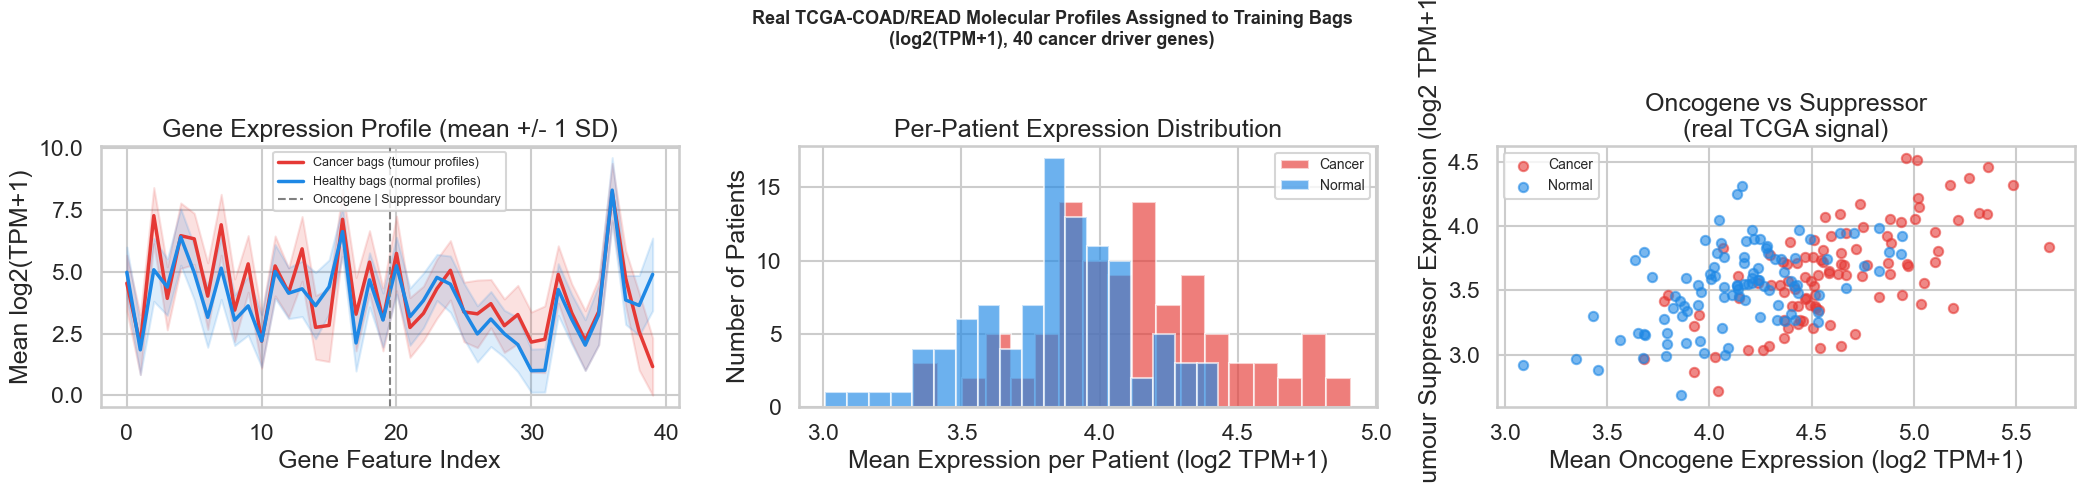

Signal check (real TCGA data, training bags):
  Cancer  -- oncogene mean: 4.612  suppressor mean: 3.631
  Normal  -- oncogene mean: 4.139  suppressor mean: 3.522


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

labels_arr  = np.array(train_bag_labels)
cancer_mol  = mol_train[labels_arr == 1.0]   # (100, 40) -- cancer profiles
healthy_mol = mol_train[labels_arr == 0.0]   # (100, 40) -- normal profiles

fig, axes = plt.subplots(1, 3, figsize=(21, 5))
fig.suptitle(
    "Real TCGA-COAD/READ Molecular Profiles Assigned to Training Bags\n"
    "(log2(TPM+1), 40 cancer driver genes)",
    fontsize=13, fontweight="bold")

# Panel 1: Mean +/- 1SD gene expression profile across all 40 genes
ax = axes[0]
ax.plot(range(MOLECULAR_DIM), cancer_mol.mean(0),  color="#E53935", lw=2.5, label="Cancer bags (tumour profiles)")
ax.plot(range(MOLECULAR_DIM), healthy_mol.mean(0), color="#1E88E5", lw=2.5, label="Healthy bags (normal profiles)")
ax.fill_between(range(MOLECULAR_DIM),
    cancer_mol.mean(0) - cancer_mol.std(0),
    cancer_mol.mean(0) + cancer_mol.std(0), alpha=0.15, color="#E53935")
ax.fill_between(range(MOLECULAR_DIM),
    healthy_mol.mean(0) - healthy_mol.std(0),
    healthy_mol.mean(0) + healthy_mol.std(0), alpha=0.15, color="#1E88E5")
ax.axvline(19.5, color="gray", ls="--", lw=1.5, label="Oncogene | Suppressor boundary")
ax.set_xlabel("Gene Feature Index")
ax.set_ylabel("Mean log2(TPM+1)")
ax.set_title("Gene Expression Profile (mean +/- 1 SD)")
ax.legend(fontsize=9)

# Panel 2: Per-patient mean expression distribution
ax = axes[1]
ax.hist(cancer_mol.mean(1),  bins=18, color="#E53935", alpha=0.65, label="Cancer")
ax.hist(healthy_mol.mean(1), bins=18, color="#1E88E5", alpha=0.65, label="Normal")
ax.set_xlabel("Mean Expression per Patient (log2 TPM+1)")
ax.set_ylabel("Number of Patients")
ax.set_title("Per-Patient Expression Distribution")
ax.legend(fontsize=10)

# Panel 3: Oncogene activity vs Tumour Suppressor activity (real signal)
ax = axes[2]
ax.scatter(cancer_mol[:,  :20].mean(1), cancer_mol[:,  20:].mean(1),
           c="#E53935", alpha=0.6, s=45, label="Cancer")
ax.scatter(healthy_mol[:, :20].mean(1), healthy_mol[:, 20:].mean(1),
           c="#1E88E5", alpha=0.6, s=45, label="Normal")
ax.set_xlabel("Mean Oncogene Expression (log2 TPM+1)")
ax.set_ylabel("Mean Tumour Suppressor Expression (log2 TPM+1)")
ax.set_title("Oncogene vs Suppressor\n(real TCGA signal)")
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("Signal check (real TCGA data, training bags):")
print(f"  Cancer  -- oncogene mean: {cancer_mol[:,:20].mean():.3f}  suppressor mean: {cancer_mol[:,20:].mean():.3f}")
print(f"  Normal  -- oncogene mean: {healthy_mol[:,:20].mean():.3f}  suppressor mean: {healthy_mol[:,20:].mean():.3f}")

In [12]:
import pickle

# ============================================================
# SAVE ALL ARTIFACTS
# artifacts/
#   preprocessing.pkl      -- bags, labels, mol features, gene names
#   tcga_tumor_expr.pkl    -- cached GDC tumour download  (already saved above)
#   tcga_normal_expr.pkl   -- cached GDC normal download  (already saved above)
#   mol_train.npy          -- (200, 40) float32  real TCGA log2(TPM+1) profiles
#   mol_test.npy           -- ( 60, 40) float32  real TCGA log2(TPM+1) profiles
# ============================================================

artifacts = {
    "train_bags":            train_bags,
    "train_bag_labels":      train_bag_labels,
    "test_bags":             test_bags,
    "test_bag_labels":       test_bag_labels,
    "train_tumor_idx":       train_tumor_idx,
    "train_hard_normal_idx": train_hard_normal_idx,
    "test_tumor_idx":        test_tumor_idx,
    "test_hard_normal_idx":  test_hard_normal_idx,
    "mol_train":             mol_train,
    "mol_test":              mol_test,
    "cancer_genes":          CANCER_GENES,
    "oncogenes":             ONCOGENES,
    "tumor_suppressors":     TUMOR_SUPPRESSORS,
    "MOLECULAR_DIM":         MOLECULAR_DIM,
}

with open(os.path.join(ARTIFACTS_DIR, "preprocessing.pkl"), "wb") as f:
    pickle.dump(artifacts, f)
np.save(os.path.join(ARTIFACTS_DIR, "mol_train.npy"), mol_train)
np.save(os.path.join(ARTIFACTS_DIR, "mol_test.npy"),  mol_test)

print("Artifacts saved to artifacts/:")
print(f"  preprocessing.pkl     ({N_TRAIN_BAGS} train bags, {N_TEST_BAGS} test bags)")
print(f"  mol_train.npy         {mol_train.shape} float32  (real TCGA log2 TPM+1)")
print(f"  mol_test.npy          {mol_test.shape}  float32  (real TCGA log2 TPM+1)")
print(f"  tcga_tumor_expr.pkl   {tumor_expr.shape} (cached GDC download)")
print(f"  tcga_normal_expr.pkl  {normal_expr.shape} (cached GDC download)")
print("\nPreprocessing complete. Run 03_feature_extraction_and_training.ipynb next.")

Artifacts saved to artifacts/:
  preprocessing.pkl     (200 train bags, 60 test bags)
  mol_train.npy         (200, 40) float32  (real TCGA log2 TPM+1)
  mol_test.npy          (60, 40)  float32  (real TCGA log2 TPM+1)
  tcga_tumor_expr.pkl   (160, 40) (cached GDC download)
  tcga_normal_expr.pkl  (51, 40) (cached GDC download)

Preprocessing complete. Run 03_feature_extraction_and_training.ipynb next.
